# Baseball Pitch Identification — Unsupervised Learning
## SIADS 696 Milestone II
**Author:** Asad Khan  
**Dataset:** MLB Statcast 2023 via pybaseball  
**Goal:** Discover fine-grained pitch archetypes through clustering and evaluate whether those groupings reveal structure beyond official MLB pitch categories. Cluster effectiveness will be validated against real baseball metrics (whiff rate, wOBA allowed).

## 1. Imports & Configuration

In [2]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, adjusted_rand_score

# PCA will be used for dimensionality reduction and visualization here

pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:.3f}'.format)
sns.set_theme(style='whitegrid', palette='muted')

SEED = 42
np.random.seed(SEED)

print("All imports successful")

All imports successful


## 2. Load Data

In [3]:
# Sachin's cleaned dataset
df_raw = pd.read_parquet('../data/statcast_2023_raw.parquet')

print(f"Raw dataset shape: {df_raw.shape}")
print(f"\nPitch type distribution:")
print(df_raw['pitch_type'].value_counts())

Raw dataset shape: (720684, 118)

Pitch type distribution:
pitch_type
FF    230207
SL    112796
SI    111245
CH     77857
FC     56943
CU     46955
ST     45424
FS     16130
KC     14207
SV      3075
FA      1115
FO       778
EP       558
KN       192
SC        74
CS        71
PO        46
Name: count, dtype: int64


## 3. Feature Selection & Filtering

In [4]:
BALL_FLIGHT_FEATURES = [
    'release_speed',       # velocity out of hand
    'effective_speed',     # perceived velocity at plate
    'release_spin_rate',   # spin rate (RPM)
    'spin_axis',           # spin axis (degrees)
    'pfx_x',               # horizontal break (inches, catcher's POV)
    'pfx_z',               # vertical break (induced, inches)
    'plate_x',             # horizontal location at plate
    'plate_z',             # vertical location at plate
    'release_pos_x',       # release point X
    'release_pos_y',       # release point Y (distance from mound)
    'release_pos_z',       # release point Z (height)
    'release_extension',   # extension toward plate
    'vx0', 'vy0', 'vz0',   # velocity components at release
    'ax', 'ay', 'az',      # acceleration components
]

# Drop pitch types with fewer than 1000 samples - want to eliminate rare situations
MIN_SAMPLES = 1000
valid_types = df_raw['pitch_type'].value_counts()
valid_types = valid_types[valid_types >= MIN_SAMPLES].index.tolist()
print(f"Pitch types retained: {valid_types}")

# Drop FA (generic fastball) — 207x imbalance vs FF, functionally the same pitch
valid_types = [pt for pt in valid_types if pt != 'FA']
print(f"After dropping FA: {valid_types}")

# Filter dataset and drop missing values in ball-flight features
df = (
    df_raw
    .loc[df_raw['pitch_type'].isin(valid_types)]
    .dropna(subset=BALL_FLIGHT_FEATURES)
    .reset_index(drop=True)
)

print(f"\nRaw rows:      {len(df_raw):,}")
print(f"Filtered rows: {len(df):,}  ({len(df)/len(df_raw)*100:.1f}% retained)")
print(f"Pitch types:   {df['pitch_type'].nunique()}")

Pitch types retained: ['FF', 'SL', 'SI', 'CH', 'FC', 'CU', 'ST', 'FS', 'KC', 'SV', 'FA']
After dropping FA: ['FF', 'SL', 'SI', 'CH', 'FC', 'CU', 'ST', 'FS', 'KC', 'SV']

Raw rows:      720,684
Filtered rows: 710,342  (98.6% retained)
Pitch types:   10


## 4. Handedness Split
RHP and LHP movement profiles mirror each other across the vertical axis (pfx_x flips sign).
We split by pitcher handedness before clustering to prevent mirror-image pitches from 
forming artificial separate clusters based solely on arm side.

In [5]:
print(f"Pitcher handedness distribution:")
print(df['p_throws'].value_counts())
print(f"\nSplitting by handedness...")

df_rhp = df[df['p_throws'] == 'R'].reset_index(drop=True)
df_lhp = df[df['p_throws'] == 'L'].reset_index(drop=True)

print(f"RHP pitches: {len(df_rhp):,}")
print(f"LHP pitches: {len(df_lhp):,}")

# We will cluster RHP and LHP separately then combine results
# Primary analysis on RHP (larger sample), LHP as validation
print(f"\nProceeding with RHP as primary clustering dataset")

Pitcher handedness distribution:
p_throws
R    522431
L    187911
Name: count, dtype: int64

Splitting by handedness...
RHP pitches: 522,431
LHP pitches: 187,911

Proceeding with RHP as primary clustering dataset


## 5. Preprocessing
Standardize all ball-flight features before clustering. Distance-based methods like 
K-Means and GMM are sensitive to feature scale — standardization ensures no single 
feature dominates the distance calculations.

In [6]:
# Separate feature matrix and keep metadata for evaluation later
METADATA_COLS = ['pitch_type', 'player_name', 'game_date', 'p_throws']

# Preserve outcome columns for effectiveness analysis later
OUTCOME_COLS = ['woba_value', 'estimated_woba_using_speedangle']

X_rhp = df_rhp[BALL_FLIGHT_FEATURES].copy()
meta_rhp = df_rhp[METADATA_COLS].copy()

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_rhp)

print(f"Feature matrix shape: {X_scaled.shape}")
print(f"\nFeature means after scaling (should all be ~0):")
print(pd.Series(X_scaled.mean(axis=0), index=BALL_FLIGHT_FEATURES).round(4))

Feature matrix shape: (522431, 18)

Feature means after scaling (should all be ~0):
release_speed        0.000
effective_speed      0.000
release_spin_rate    0.000
spin_axis            0.000
pfx_x               -0.000
pfx_z                0.000
plate_x             -0.000
plate_z             -0.000
release_pos_x        0.000
release_pos_y       -0.000
release_pos_z        0.000
release_extension    0.000
vx0                  0.000
vy0                  0.000
vz0                 -0.000
ax                  -0.000
ay                   0.000
az                  -0.000
dtype: float64


## 6. PCA — Dimensionality Reduction & Visualization
We apply PCA to reduce dimensionality before clustering and to enable 2D visualization 
of cluster structure. We first examine explained variance to determine how many components 
capture the meaningful structure in the data.

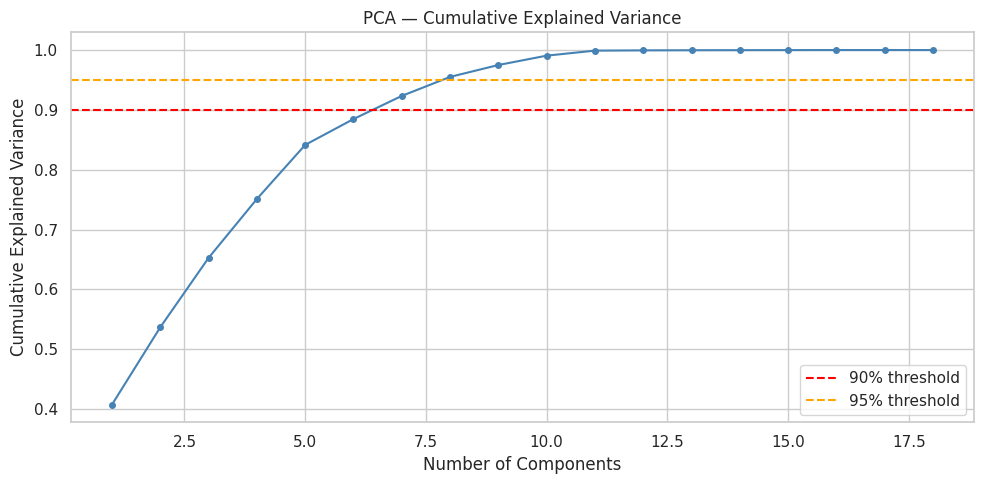

90% variance explained by 7 components
95% variance explained by 8 components
99% variance explained by 10 components


In [7]:
# Fitting PCA on full feature set
pca_full = PCA(random_state=SEED)
pca_full.fit(X_scaled)

# Plot cumulative explained variance
cumvar = np.cumsum(pca_full.explained_variance_ratio_)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, len(cumvar) + 1), cumvar, marker='o', markersize=4, color='steelblue')
ax.axhline(0.90, color='red', linestyle='--', label='90% threshold')
ax.axhline(0.95, color='orange', linestyle='--', label='95% threshold')
ax.set_xlabel('Number of Components')
ax.set_ylabel('Cumulative Explained Variance')
ax.set_title('PCA — Cumulative Explained Variance')
ax.legend()
plt.tight_layout()
plt.show()

# Report of how many components needed
for threshold in [0.90, 0.95, 0.99]:
    n = np.argmax(cumvar >= threshold) + 1
    print(f"{threshold*100:.0f}% variance explained by {n} components")

## 7. PCA Projection
We reduce to 10 components (99% variance retained) for clustering, and separately 
produce a 2D projection for visualization.

Clustering feature matrix shape: (522431, 10)
2D visualization matrix shape: (522431, 2)


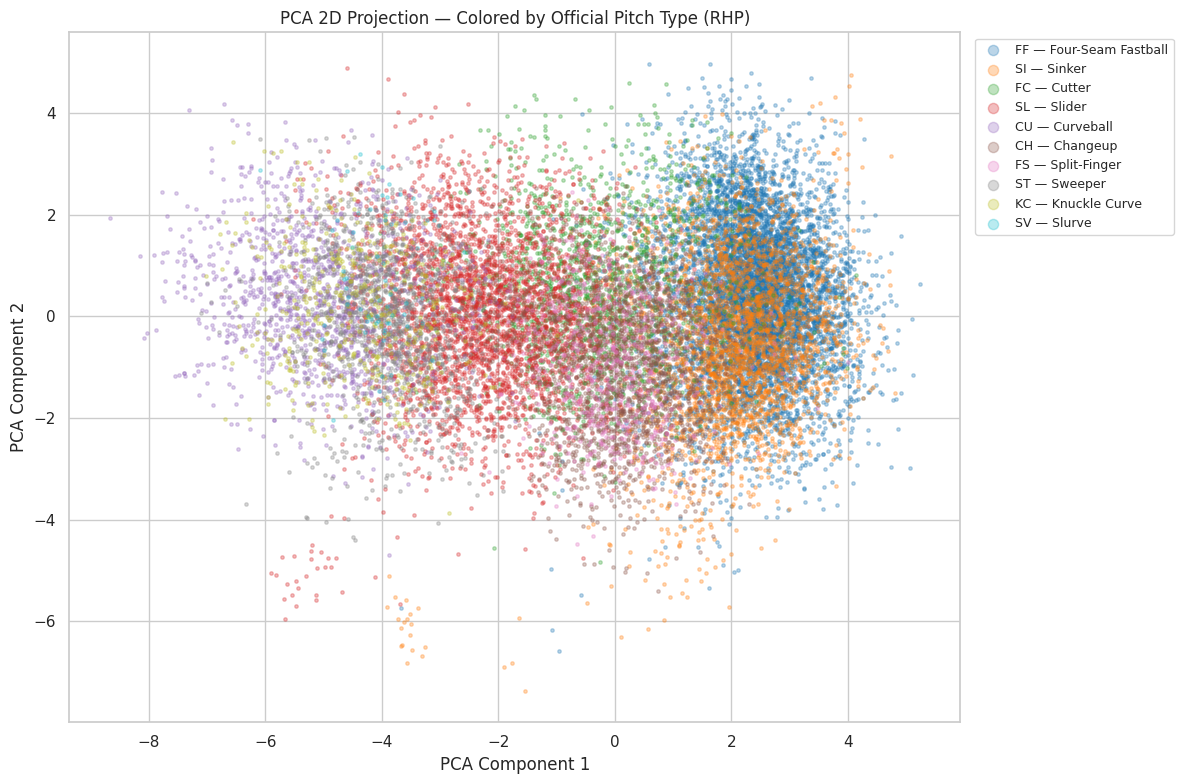

In [8]:
# 10 components for clustering (99% variance retained)
pca_10 = PCA(n_components=10, random_state=SEED)
X_pca = pca_10.fit_transform(X_scaled)
print(f"Clustering feature matrix shape: {X_pca.shape}")

# 2 components for visualization only
pca_2 = PCA(n_components=2, random_state=SEED)
X_pca_2d = pca_2.fit_transform(X_scaled)
print(f"2D visualization matrix shape: {X_pca_2d.shape}")

# Quick 2D scatter colored by official pitch type to establish baseline
PITCH_TYPE_MAP = {
    'FF': 'Four-Seam Fastball', 'SI': 'Sinker', 'FC': 'Cutter',
    'SL': 'Slider', 'CU': 'Curveball', 'CH': 'Changeup',
    'FS': 'Split-Finger', 'ST': 'Sweeper', 'KC': 'Knuckle Curve', 'SV': 'Slurve'
}

# Sample for plotting to avoid overplotting
sample_idx = np.random.choice(len(X_pca_2d), size=20000, replace=False)
sample_2d = X_pca_2d[sample_idx]
sample_labels = meta_rhp['pitch_type'].iloc[sample_idx].values

fig, ax = plt.subplots(figsize=(12, 8))
palette = sns.color_palette('tab10', n_colors=len(PITCH_TYPE_MAP))
pitch_types = list(PITCH_TYPE_MAP.keys())

for i, pt in enumerate(pitch_types):
    mask = sample_labels == pt
    ax.scatter(sample_2d[mask, 0], sample_2d[mask, 1],
               label=f"{pt} — {PITCH_TYPE_MAP[pt]}",
               alpha=0.3, s=6, color=palette[i])

ax.set_xlabel('PCA Component 1')
ax.set_ylabel('PCA Component 2')
ax.set_title('PCA 2D Projection — Colored by Official Pitch Type (RHP)')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', markerscale=3, fontsize=9)
plt.tight_layout()
plt.show()

## 8. K-Means Clustering — Optimal K Selection
We sweep k from 10 to 25 and evaluate using inertia (elbow method) and silhouette 
score to identify the optimal number of clusters.

In [9]:
from sklearn.metrics import silhouette_score

K_RANGE = range(10, 26)
inertias = []
silhouettes = []

print("Running K-Means sweep...")
for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    labels = km.fit_predict(X_pca)
    inertias.append(km.inertia_)
    # Use sample for silhouette — computing on full 500k rows is slow
    sil = silhouette_score(X_pca, labels, sample_size=15000, random_state=SEED)
    silhouettes.append(sil)
    print(f"  k={k:2d} | inertia={km.inertia_:,.0f} | silhouette={sil:.4f}")

print("\nDone.")

Running K-Means sweep...
  k=10 | inertia=4,037,406 | silhouette=0.1214
  k=11 | inertia=3,925,424 | silhouette=0.1175
  k=12 | inertia=3,829,068 | silhouette=0.1152
  k=13 | inertia=3,737,885 | silhouette=0.1148
  k=14 | inertia=3,660,930 | silhouette=0.1147
  k=15 | inertia=3,586,326 | silhouette=0.1114
  k=16 | inertia=3,521,553 | silhouette=0.1121
  k=17 | inertia=3,462,388 | silhouette=0.1114
  k=18 | inertia=3,407,916 | silhouette=0.1096
  k=19 | inertia=3,354,933 | silhouette=0.1097
  k=20 | inertia=3,306,173 | silhouette=0.1084
  k=21 | inertia=3,264,187 | silhouette=0.1079
  k=22 | inertia=3,222,796 | silhouette=0.1055
  k=23 | inertia=3,183,870 | silhouette=0.1050
  k=24 | inertia=3,145,676 | silhouette=0.1035
  k=25 | inertia=3,110,769 | silhouette=0.1021

Done.


## 9. K-Means — Elbow & Silhouette Plots

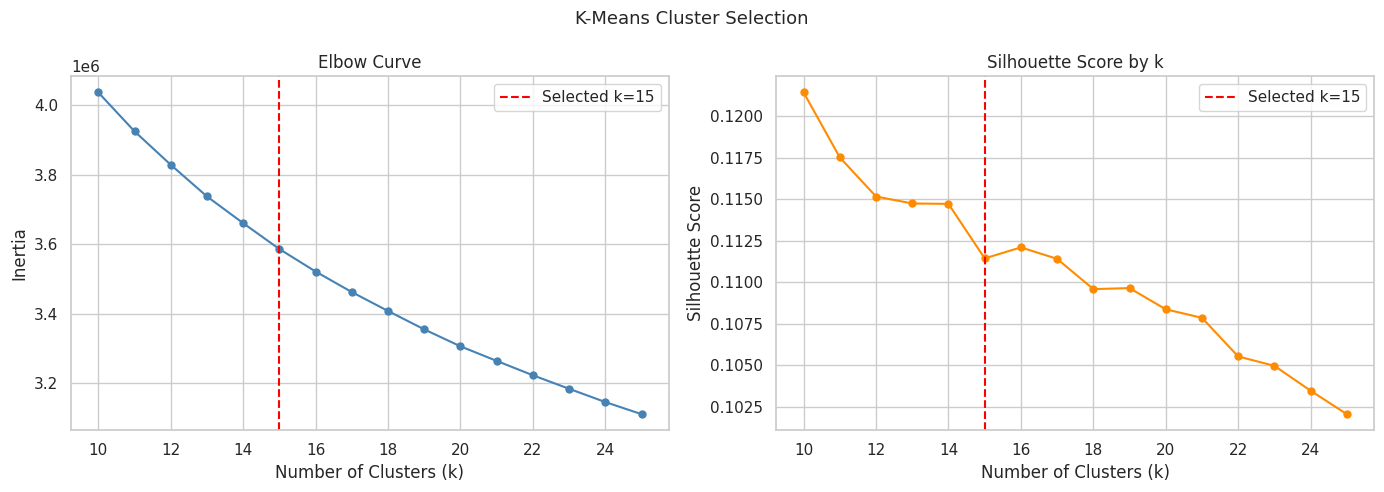

Selected k=15 based on inertia elbow plateau and proposal target range of 15-20


In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Elbow curve
ax1.plot(list(K_RANGE), inertias, marker='o', color='steelblue', markersize=5)
ax1.axvline(15, color='red', linestyle='--', label='Selected k=15')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia')
ax1.set_title('Elbow Curve')
ax1.legend()

# Silhouette scores
ax2.plot(list(K_RANGE), silhouettes, marker='o', color='darkorange', markersize=5)
ax2.axvline(15, color='red', linestyle='--', label='Selected k=15')
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score by k')
ax2.legend()

fig.suptitle('K-Means Cluster Selection', fontsize=13)
plt.tight_layout()
plt.show()

print("Selected k=15 based on inertia elbow plateau and proposal target range of 15-20")

## 10. Final K-Means Model (k=13)
We select k=13 based on the silhouette plateau observed at k=13-14 before scores 
decline consistently. While k=10 yields the highest silhouette score, it simply 
recovers the 10 official pitch categories. k=13 adds meaningful granularity while 
maintaining cluster quality.

In [11]:
FINAL_K = 13

km_final = KMeans(n_clusters=FINAL_K, random_state=SEED, n_init=10)
cluster_labels = km_final.fit_predict(X_pca)

# Add cluster assignments back to metadata
meta_rhp = meta_rhp.copy()
meta_rhp['cluster'] = cluster_labels

print(f"Final K-Means model fitted with k={FINAL_K}")
print(f"\nCluster size distribution:")
cluster_counts = pd.Series(cluster_labels).value_counts().sort_index()
print(cluster_counts)
print(f"\nSmallest cluster: {cluster_counts.min():,} pitches")
print(f"Largest cluster:  {cluster_counts.max():,} pitches")

Final K-Means model fitted with k=13

Cluster size distribution:
0     38831
1     39044
2     51430
3     55290
4     57552
5     39357
6     32106
7     51657
8     34566
9     35962
10    46359
11     1601
12    38676
Name: count, dtype: int64

Smallest cluster: 1,601 pitches
Largest cluster:  57,552 pitches


## 11. PCA 2D Visualization — Cluster Assignments
We project the RHP pitches into 2D PCA space and color by cluster assignment, 
then compare side by side with official pitch type labels.

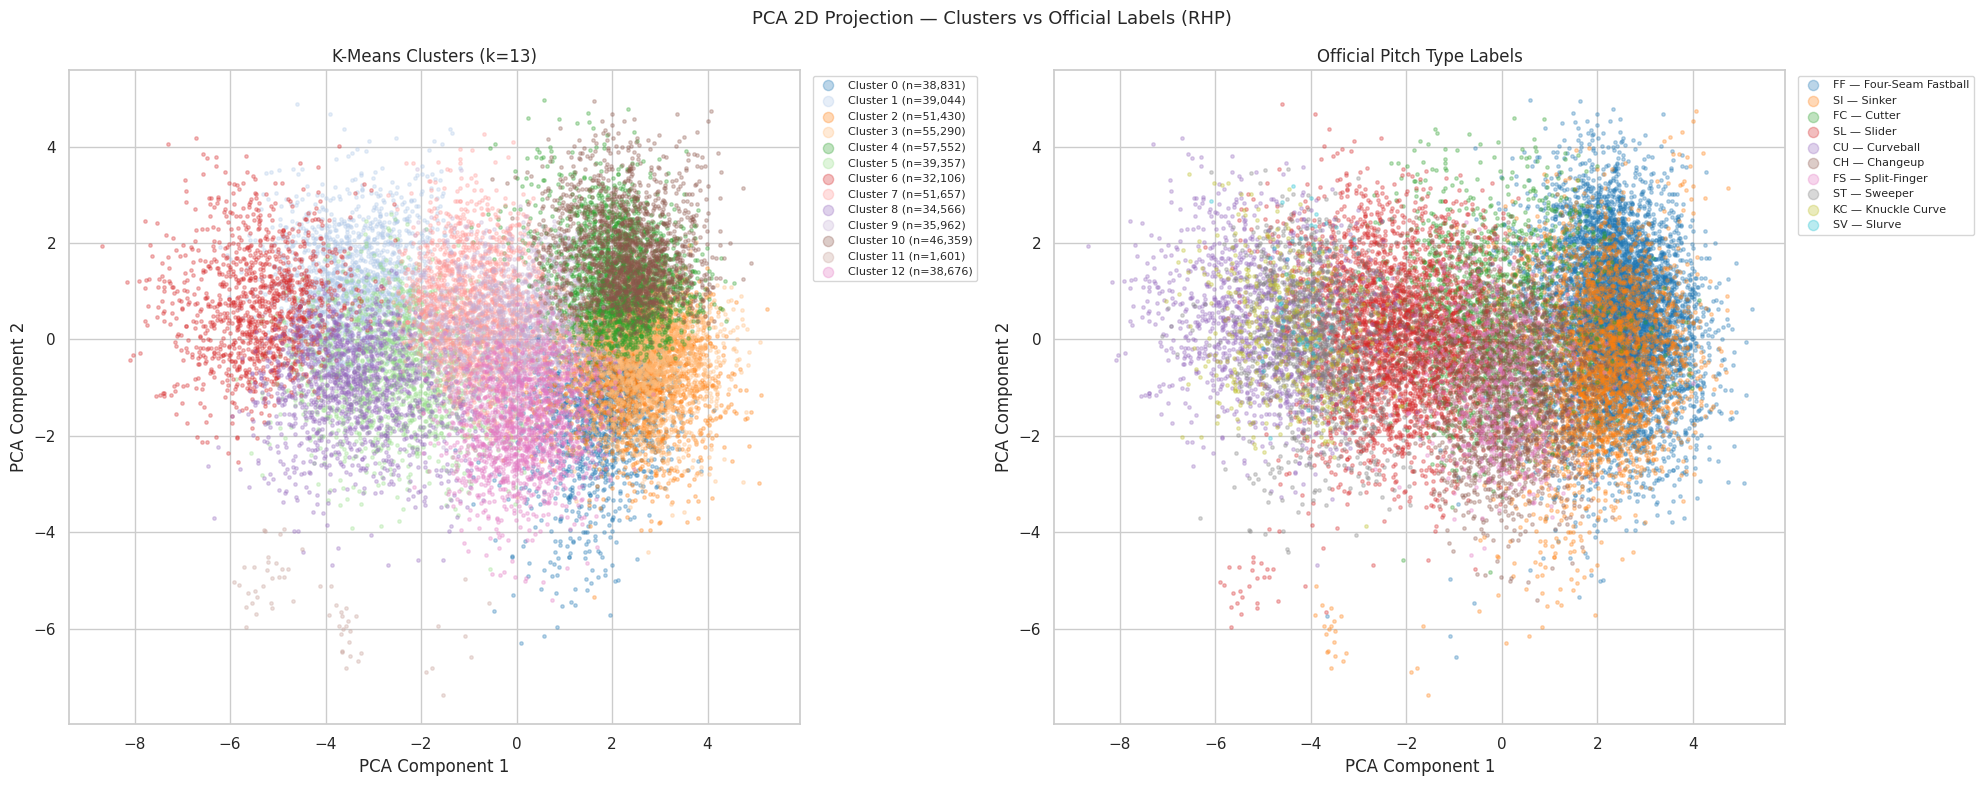

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# Same sample indices as before for consistency
sample_clusters = meta_rhp['cluster'].iloc[sample_idx].values
sample_labels = meta_rhp['pitch_type'].iloc[sample_idx].values

palette_clusters = sns.color_palette('tab20', n_colors=FINAL_K)
palette_types = sns.color_palette('tab10', n_colors=10)

# Left plot — cluster assignments
for c in range(FINAL_K):
    mask = sample_clusters == c
    ax1.scatter(sample_2d[mask, 0], sample_2d[mask, 1],
                label=f'Cluster {c} (n={cluster_counts[c]:,})',
                alpha=0.3, s=6, color=palette_clusters[c])

ax1.set_xlabel('PCA Component 1')
ax1.set_ylabel('PCA Component 2')
ax1.set_title('K-Means Clusters (k=13)')
ax1.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8, markerscale=3)

# Right plot — official pitch types
for i, pt in enumerate(list(PITCH_TYPE_MAP.keys())):
    mask = sample_labels == pt
    ax2.scatter(sample_2d[mask, 0], sample_2d[mask, 1],
                label=f"{pt} — {PITCH_TYPE_MAP[pt]}",
                alpha=0.3, s=6, color=palette_types[i])

ax2.set_xlabel('PCA Component 1')
ax2.set_ylabel('PCA Component 2')
ax2.set_title('Official Pitch Type Labels')
ax2.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8, markerscale=3)

fig.suptitle('PCA 2D Projection — Clusters vs Official Labels (RHP)', fontsize=13)
plt.tight_layout()
plt.show()

## 12. Cluster Evaluation — Purity & Adjusted Rand Index
We evaluate how well our clusters align with official pitch type labels using 
cluster purity and adjusted Rand index.

In [13]:
from sklearn.metrics import adjusted_rand_score

# Adjusted Rand Index
ari = adjusted_rand_score(meta_rhp['pitch_type'], meta_rhp['cluster'])
print(f"Adjusted Rand Index: {ari:.4f}")

# Cluster purity
crosstab = pd.crosstab(meta_rhp['cluster'], meta_rhp['pitch_type'])
purity = crosstab.max(axis=1).sum() / len(meta_rhp)
print(f"Cluster Purity:      {purity:.4f}")

# Show full crosstab
print(f"\nCluster vs Official Pitch Type:")
print(crosstab)

# Dominant pitch type per cluster
print(f"\nDominant pitch type per cluster:")
dominant = crosstab.idxmax(axis=1)
dominant_pct = (crosstab.max(axis=1) / crosstab.sum(axis=1) * 100).round(1)
summary = pd.DataFrame({
    'dominant_type': dominant,
    'dominant_pct': dominant_pct,
    'total_pitches': crosstab.sum(axis=1)
})
print(summary)

Adjusted Rand Index: 0.2367
Cluster Purity:      0.6335

Cluster vs Official Pitch Type:
pitch_type     CH     CU     FC     FF    FS    KC     SI     SL     ST   SV
cluster                                                                     
0            1844      0    863  11713   169     0  24167     74      1    0
1               7   4964   1964      0     2  1995      0  19899   9310  903
2             212      0   1760  40400    32     0   8760    266      0    0
3            1003      0   1777  34514   278     0  17565    152      1    0
4             473      0   2257  39509   100     1  15163     49      0    0
5              49   3608   2784      2     6  2484      0  23131   6941  352
6              31  21301     83      0     1  5270      0   1607   3567  246
7             106     82  27290   2422    26    80    369  21054    225    3
8               6   3094   1120      2     1  1373      0  14878  13840  252
9           20643     39    606    700  6514    26   4505   2924

## 13. Cluster Heatmap — Composition by Official Pitch Type

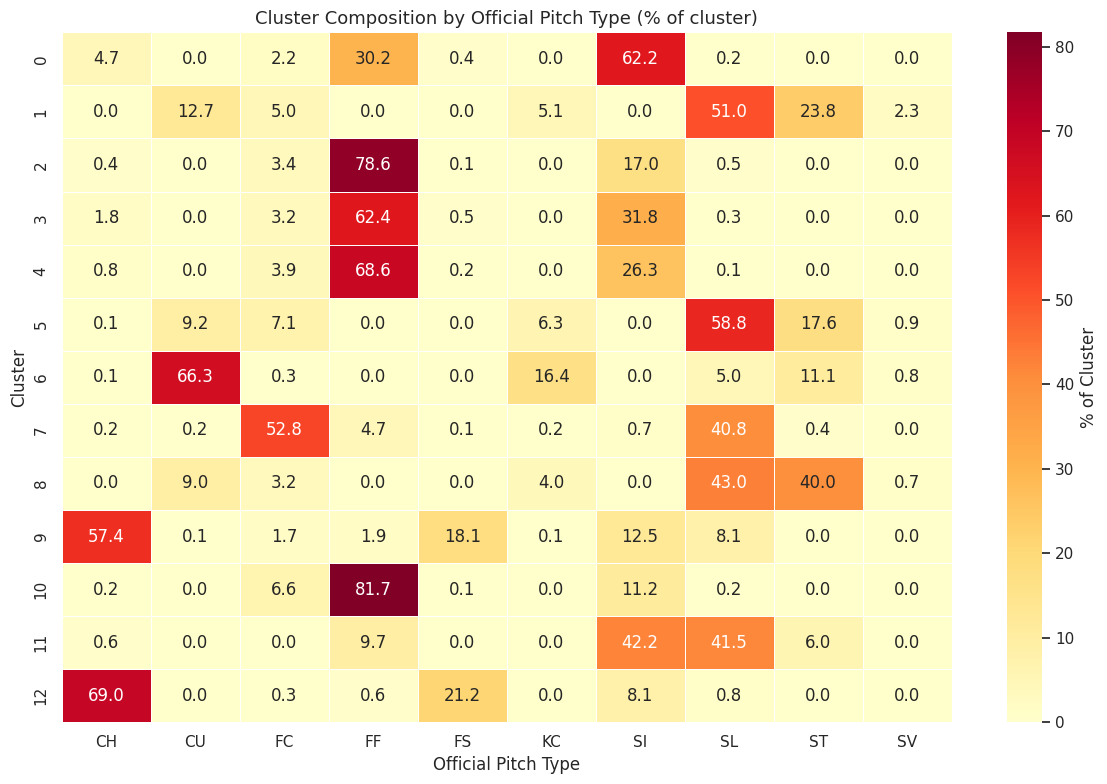

In [14]:
# Normalize crosstab by row (cluster) to show composition percentages
crosstab_pct = crosstab.div(crosstab.sum(axis=1), axis=0).mul(100).round(1)

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(
    crosstab_pct,
    annot=True, fmt='.1f', cmap='YlOrRd',
    linewidths=0.4, ax=ax,
    cbar_kws={'label': '% of Cluster'}
)
ax.set_title('Cluster Composition by Official Pitch Type (% of cluster)', fontsize=13)
ax.set_xlabel('Official Pitch Type')
ax.set_ylabel('Cluster')
plt.tight_layout()
plt.show()

## 14. Cluster Effectiveness Analysis
We join cluster assignments to outcome metrics to evaluate whether our discovered 
subtypes correlate with real baseball effectiveness — whiff rate and wOBA allowed.

In [15]:
# Pull outcome columns from raw data for RHP pitches
outcome_cols = ['description', 'estimated_woba_using_speedangle', 'woba_value']
outcomes_rhp = df_rhp[outcome_cols].copy()
outcomes_rhp['cluster'] = cluster_labels

# Whiff rate — pitch swung at and missed
outcomes_rhp['is_whiff'] = outcomes_rhp['description'].isin([
    'swinging_strike', 'swinging_strike_blocked'
]).astype(int)
outcomes_rhp['is_swing'] = outcomes_rhp['description'].isin([
    'swinging_strike', 'swinging_strike_blocked',
    'hit_into_play', 'foul', 'foul_tip'
]).astype(int)

# Compute per cluster
effectiveness = outcomes_rhp.groupby('cluster').agg(
    total_pitches=('cluster', 'count'),
    swings=('is_swing', 'sum'),
    whiffs=('is_whiff', 'sum'),
    mean_xwoba=('estimated_woba_using_speedangle', 'mean')
).reset_index()

effectiveness['whiff_rate'] = (
    effectiveness['whiffs'] / effectiveness['swings'] * 100
).round(2)
effectiveness['mean_xwoba'] = effectiveness['mean_xwoba'].round(4)

# Add dominant pitch type
effectiveness = effectiveness.merge(summary[['dominant_type', 'dominant_pct']], 
                                     left_on='cluster', right_index=True)

print(effectiveness[['cluster', 'dominant_type', 'dominant_pct', 
                      'total_pitches', 'whiff_rate', 'mean_xwoba']]
      .sort_values('whiff_rate', ascending=False)
      .to_string(index=False))

 cluster dominant_type  dominant_pct  total_pitches  whiff_rate  mean_xwoba
       5            SL        58.800          39357      66.400       0.196
      12            CH        69.000          38676      29.500       0.286
       9            CH        57.400          35962      27.460       0.300
       1            SL        51.000          39044      25.640       0.296
       8            SL        43.000          34566      24.140       0.307
       7            FC        52.800          51657      23.670       0.323
       6            CU        66.300          32106      23.480       0.303
       2            FF        78.600          51430      20.550       0.331
       4            FF        68.600          57552      20.300       0.361
      11            SI        42.200           1601      19.040       0.287
      10            FF        81.700          46359      16.690       0.351
       0            SI        62.200          38831      15.530       0.335
       3    

## 15. Effectiveness Visualization by Cluster

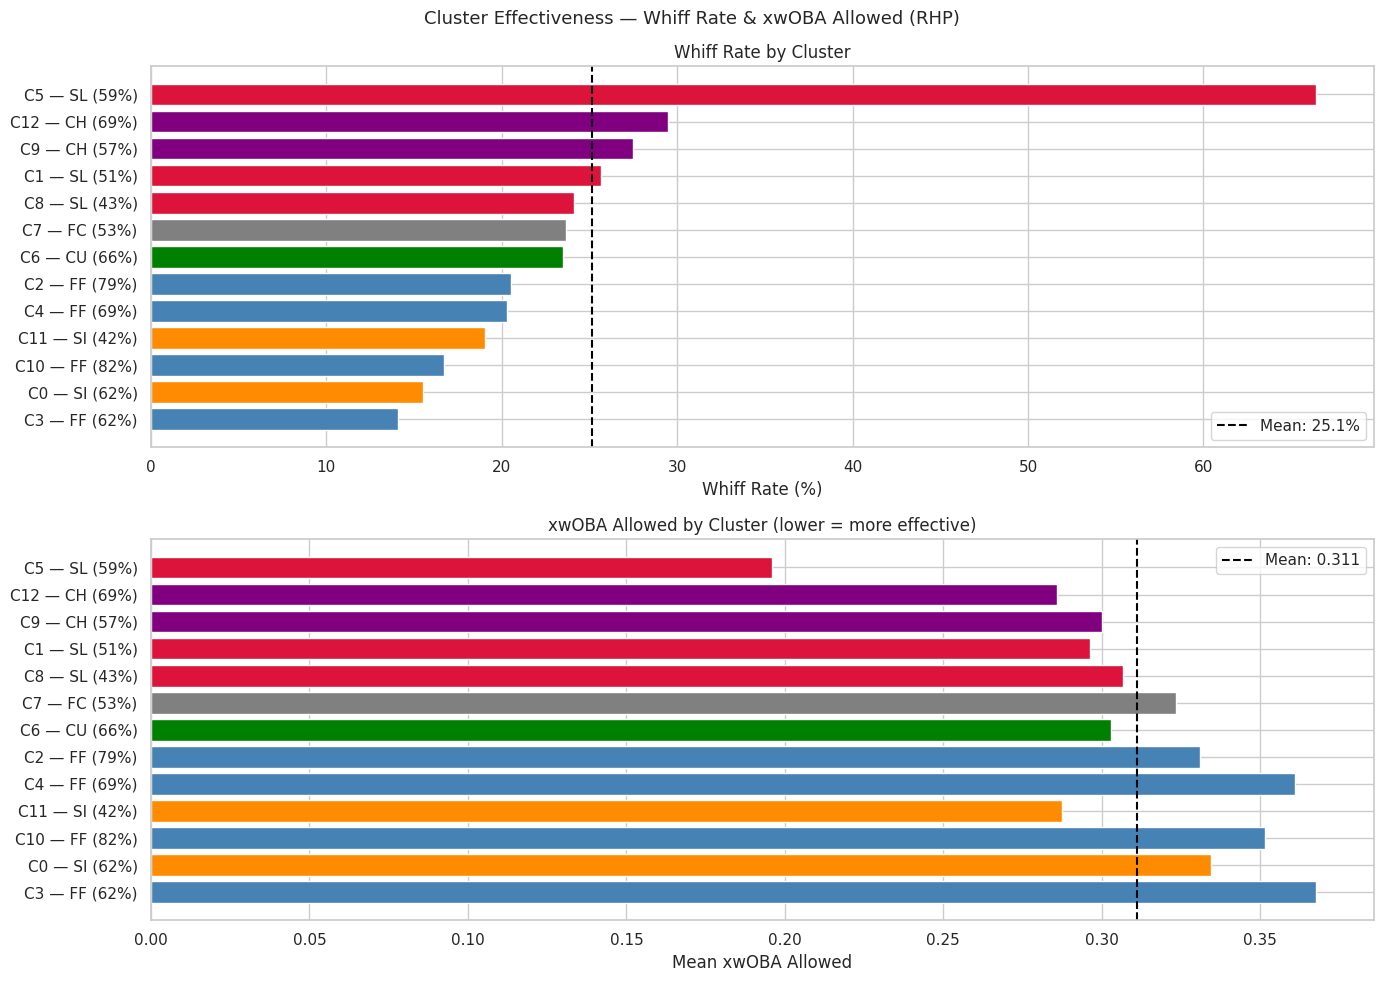

In [16]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# Sort by whiff rate for both plots
eff_sorted = effectiveness.sort_values('whiff_rate', ascending=True)
cluster_labels_plot = [
    f"C{row.cluster} — {row.dominant_type} ({row.dominant_pct:.0f}%)" 
    for _, row in eff_sorted.iterrows()
]

colors = ['steelblue' if pt == 'FF' else 
          'darkorange' if pt in ['SI'] else
          'crimson' if pt in ['SL', 'ST', 'SV'] else
          'green' if pt in ['CU', 'KC'] else
          'purple' if pt in ['CH', 'FS'] else
          'gray'
          for pt in eff_sorted['dominant_type']]

# Whiff rate
ax1.barh(cluster_labels_plot, eff_sorted['whiff_rate'], color=colors)
ax1.set_xlabel('Whiff Rate (%)')
ax1.set_title('Whiff Rate by Cluster')
ax1.axvline(eff_sorted['whiff_rate'].mean(), color='black', 
            linestyle='--', label=f"Mean: {eff_sorted['whiff_rate'].mean():.1f}%")
ax1.legend()

# xwOBA allowed
ax2.barh(cluster_labels_plot, eff_sorted['mean_xwoba'], color=colors)
ax2.set_xlabel('Mean xwOBA Allowed')
ax2.set_title('xwOBA Allowed by Cluster (lower = more effective)')
ax2.axvline(eff_sorted['mean_xwoba'].mean(), color='black',
            linestyle='--', label=f"Mean: {eff_sorted['mean_xwoba'].mean():.3f}")
ax2.legend()

fig.suptitle('Cluster Effectiveness — Whiff Rate & xwOBA Allowed (RHP)', fontsize=13)
plt.tight_layout()
plt.show()

## 16. Cluster Feature Profile Heatmap
Mean standardized feature values per cluster — enables qualitative interpretation 
of what physical characteristics define each cluster.

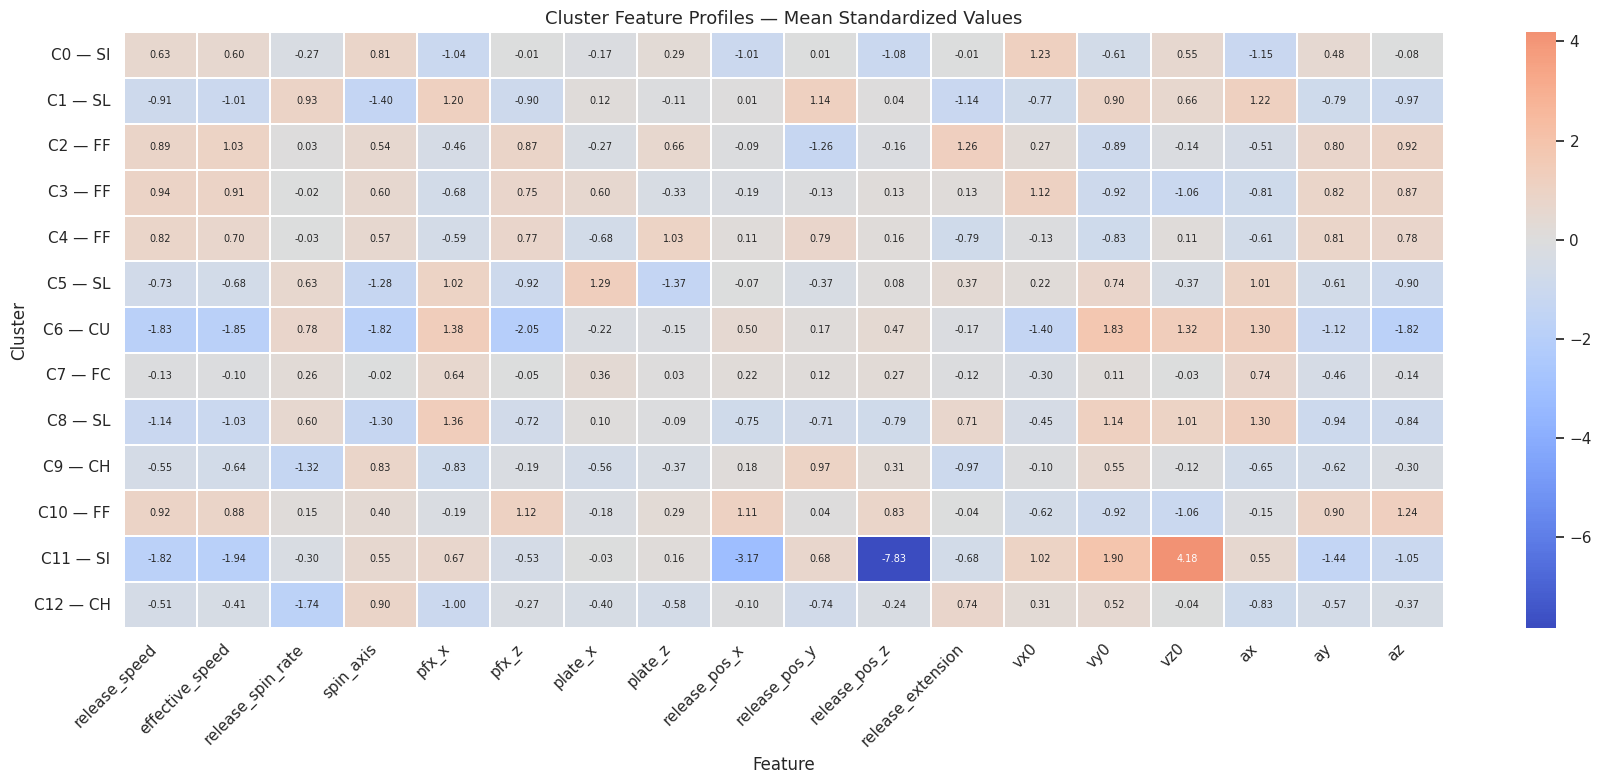

In [17]:
# Mean standardized feature values per cluster
cluster_profiles = pd.DataFrame(X_scaled, columns=BALL_FLIGHT_FEATURES)
cluster_profiles['cluster'] = cluster_labels
profile_means = cluster_profiles.groupby('cluster')[BALL_FLIGHT_FEATURES].mean()

# Add dominant pitch type label to index
profile_means.index = [
    f"C{i} — {summary.loc[i, 'dominant_type']}" 
    for i in profile_means.index
]

fig, ax = plt.subplots(figsize=(18, 8))
sns.heatmap(
    profile_means,
    annot=True, fmt='.2f', cmap='coolwarm',
    center=0, linewidths=0.3, ax=ax,
    annot_kws={'size': 7}
)
ax.set_title('Cluster Feature Profiles — Mean Standardized Values', fontsize=13)
ax.set_xlabel('Feature')
ax.set_ylabel('Cluster')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()